### Método de la Transformada Inversa

El método de la transformada inversa es una técnica utilizada para generar valores aleatorios que siguen una distribución de probabilidad específica, a partir de números aleatorios uniformes. Este método se basa en la relación entre la función de distribución y los números aleatorios uniformes.

1. **Considerar** $F$: Se parte de la función de probabilidad acumulada $F(x)$ de la distribución deseada.
2. **Generar números uniformes**: Se generan valores aleatorios  $u$  distribuidos uniformemente en el intervalo $[0, 1]$.
3. **Aplicar la inversa de la CDF**: Se calcula $x = F^{-1}(u)$, donde $F^{-1}$ es la función inversa de la CDF. Los valores $x$ obtenidos siguen la distribución deseada.

Este método es especialmente útil para distribuciones cuya CDF tiene una inversa analítica sencilla, como la distribución exponencial.

Bin width: 0.11963335092798433


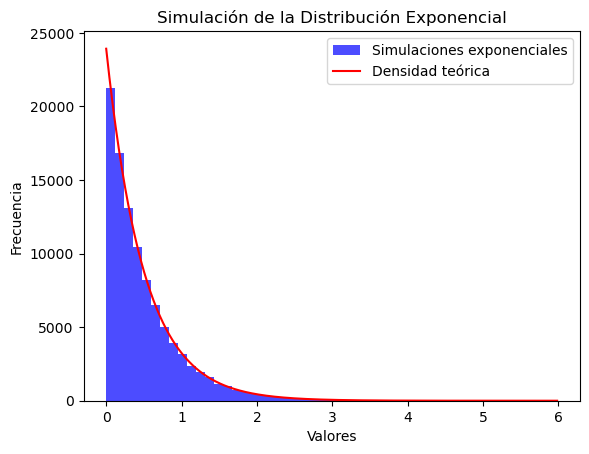

In [ ]:
import numpy as np
from scipy.stats import expon
import matplotlib.pyplot as plt

# Parámetro de la distribución exponencial (tasa lambda)
lambda_param = 2

# Número de muestras a generar
n_samples = 100000

# Generar números uniformes entre 0 y 1
uniform_random_numbers = np.random.uniform(0, 1, n_samples)

# Aplicar la transformada inversa para obtener muestras de la distribución exponencial
exponential_samples = -np.log(1 - uniform_random_numbers) / lambda_param

# Visualizar los resultados-----------------------------------------------------------
# Calcular el ancho de los bins (bin width)
bin_width = (np.max(exponential_samples) - np.min(exponential_samples)) / 50
print(f"Bin width: {bin_width}")

# Graficar el histograma
plt.hist(exponential_samples, bins=50, density = False, alpha=0.7, color='blue', label='Simulaciones exponenciales')

# Graficar la función de densidad teórica
# Crear la función de densidad teórica usando scipy.stats
# Escalar la función de densidad teórica para que corresponda al histograma de frecuencias absolutas
x = np.linspace(0, np.max(exponential_samples), 1000)
pdf = expon.pdf(x, scale=1/lambda_param) * len(exponential_samples) *  bin_width
plt.plot(x, pdf, 'r-', label='Densidad teórica')

plt.title('Simulación de la Distribución Exponencial')
plt.xlabel('Valores')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

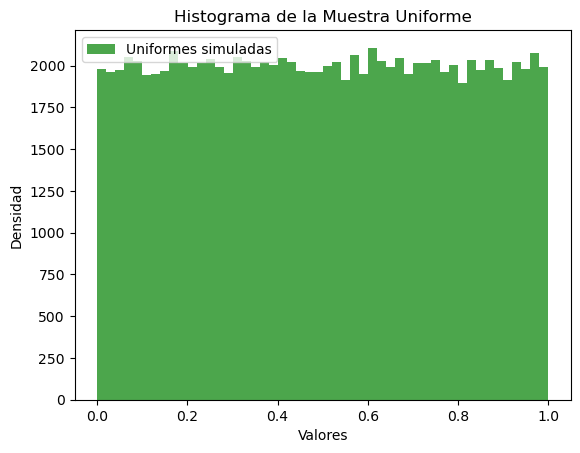

In [ ]:
plt.hist(uniform_random_numbers, bins=50, density=False, alpha=0.7, color='green', label='Uniformes simuladas')
plt.title('Histograma de la Muestra Uniforme')
plt.xlabel('Valores')
plt.ylabel('Densidad')
plt.legend()
plt.show()

In [ ]:
# Definir el evento complejo: tiempo de vida entre 2 y 4 años
evento = (exponential_samples >= 2) & (exponential_samples <= 4)

# Calcular la probabilidad usando Montecarlo
probabilidad_evento = np.sum(evento) / len(exponential_samples)

print(f"La probabilidad de que el tiempo de vida del foco esté entre 2 y 4 años es aproximadamente {probabilidad_evento:.4f}")

La probabilidad de que el tiempo de vida del foco esté entre 2 y 4 años es aproximadamente 0.0179


In [ ]:
np.exp(-4)-np.exp(-8)

0.017980176260831666

/tmp/ipython-input-3871942384.py:68: UserWarning: Glyph 129472 (\N{CHEESE WEDGE}) missing from font(s) DejaVu Sans.
  anim.save(gif_path, writer=PillowWriter(fps=12))


GIF guardado como: rata_queso.gif


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 129472 (\N{CHEESE WEDGE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129472 (\N{CHEESE WEDGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


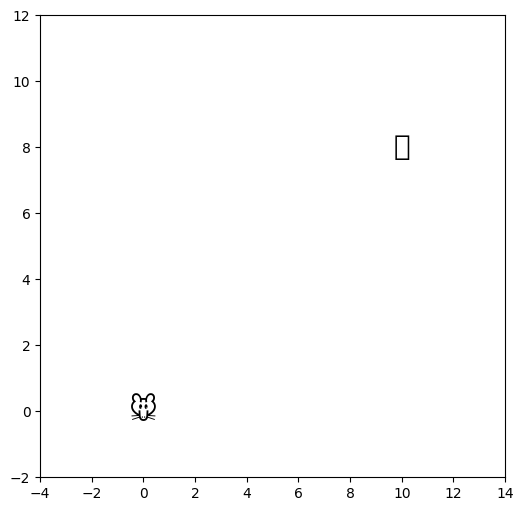

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Parámetros
n_steps = 200
start = np.array([0, 0])
goal = np.array([10, 8])

# Función para elegir un paso con sesgo hacia el objetivo
def biased_step(pos, goal):
    directions = {
        "N": np.array([0, 1]),
        "S": np.array([0, -1]),
        "E": np.array([1, 0]),
        "W": np.array([-1, 0])
    }
    vec = goal - pos
    probs = {"N":1, "S":1, "E":1, "W":1}

    # Sesgo: las dos direcciones correctas tienen 1.5x probabilidad
    if vec[1] > 0:  # objetivo al norte
        probs["N"] *= 1.5
    else:
        probs["S"] *= 1.5

    if vec[0] > 0:  # objetivo al este
        probs["E"] *= 1.5
    else:
        probs["W"] *= 1.5

    keys = list(probs.keys())
    p = np.array(list(probs.values()))
    p = p / p.sum()

    step = directions[np.random.choice(keys, p=p)]
    return step

# Simulación
path = [start.copy()]
pos = start.copy()

for _ in range(n_steps):
    pos = pos + biased_step(pos, goal)
    path.append(pos.copy())

path = np.array(path)

# Crear animación
fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlim(min(path[:,0].min(), goal[0]) - 2, max(path[:,0].max(), goal[0]) + 2)
ax.set_ylim(min(path[:,1].min(), goal[1]) - 2, max(path[:,1].max(), goal[1]) + 2)

rat_text = ax.text(path[0,0], path[0,1], "🐭", fontsize=20, ha='center', va='center')
cheese_text = ax.text(goal[0], goal[1], "🧀", fontsize=20, ha='center', va='center')
trace, = ax.plot([], [], lw=1)

def update(frame):
    rat_text.set_position((path[frame,0], path[frame,1]))
    trace.set_data(path[:frame+1,0], path[:frame+1,1])
    return rat_text, trace

anim = FuncAnimation(fig, update, frames=len(path), interval=80)

# Guardar GIF
gif_path = "rata_queso.gif"
anim.save(gif_path, writer=PillowWriter(fps=12))

print("GIF guardado como:", gif_path)

## $\pi$ es un número normal, o sea que sus dígitos aparecen un número uniforme de veces

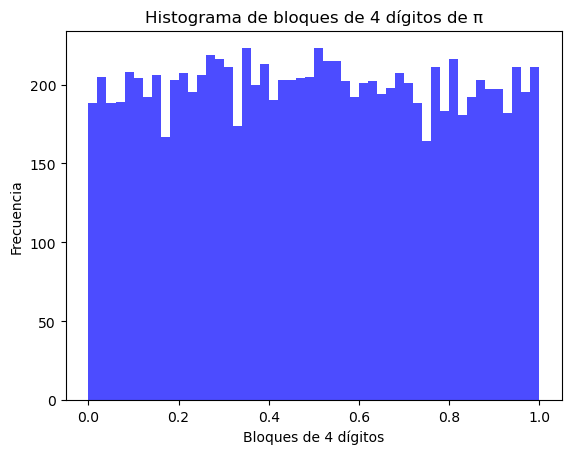

In [ ]:
from mpmath import mp

import matplotlib.pyplot as plt

# Configurar mpmath para calcular 40,000 dígitos de π
mp.dps = 40000  # Establecer la precisión a 40,000 dígitos
pi_str = str(mp.pi)[2:]  # Obtener π como cadena sin "3."

# Agrupar los dígitos en bloques de 4
U = [int(pi_str[i:i+4])/10000 for i in range(0, len(pi_str), 4)]

# Crear el histograma
plt.hist(U, bins=50, color='blue', alpha=0.7)
plt.title('Histograma de bloques de 4 dígitos de π')
plt.xlabel('Bloques de 4 dígitos')
plt.ylabel('Frecuencia')
plt.show()